In [1]:
import json
import numpy as np
from mapelite.config import PRECOMPILED_EMBEDDINGS_PATH
_dataset_path = PRECOMPILED_EMBEDDINGS_PATH
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

NS_PATH = "data/ns/"

ns_elites_path = NS_PATH + "elites.json"

with open(ns_elites_path, "r") as f:
    elites_data = json.load(f)

# print the outline of the JSON structure
metadata = elites_data["metadata"]
elites = elites_data["elites"]
print("Number of elites:", len(elites))
print("Elite keys:", elites[0].keys())

Number of elites: 200
Elite keys: dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells', 'trackSize', 'fitness', 'embedding', 'archiveIndex'])


Speed metric has 0 zeros out of 4979417 values.
Steering metric has 2376 zeros out of 4979417 values.
Distance from side metric has 0 zeros out of 4979417 values.
[ 6.48648e+01  1.33923e-02  1.36024e+01  6.44346e+01  1.25898e-02
  1.45230e+01  6.12907e+01  1.66727e-02  1.52328e+01  5.88738e+01
  1.16239e-02  1.57138e+01  5.63204e+01  9.90176e-03  1.59846e+01
  5.33297e+01  2.91854e-02  1.58849e+01  5.05997e+01  6.01993e-02
  1.50476e+01  4.80661e+01  7.13042e-02  1.38793e+01  4.53817e+01
  5.94559e-02  1.27933e+01  4.22669e+01  1.02398e-01  1.19783e+01
  3.93941e+01  1.36476e-01  1.08838e+01  3.67537e+01  9.13402e-02
  9.36253e+00  3.41676e+01  4.60505e-02  7.55041e+00  3.17199e+01
  5.13559e-02  5.56259e+00  2.98514e+01  8.20393e-02  3.61915e+00
  2.78984e+01  1.40707e-01  2.07293e+00  2.66778e+01  1.34022e-01
  1.39994e+00  2.57959e+01  1.36723e-01  1.25452e+00  2.48884e+01
  1.44432e-01  1.26951e+00  2.43360e+01  1.48668e-01  1.29597e+00
  2.38404e+01  1.63736e-01  1.28703e+00  2.31

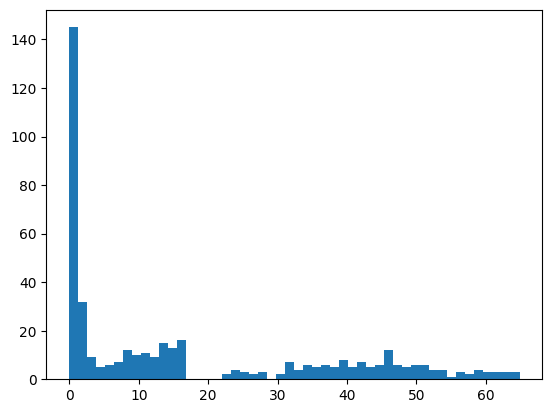

In [2]:
# load dataset at : mapelite\embeddings\datasets\dataset20k_metrics_mixedRng_tita.npz
import matplotlib.pyplot as plt

dataset = np.load("mapelite/embeddings/datasets/dataset20k_metrics_mixedRng_tita.npz")
flat_metrics = dataset["data"]
indices = dataset["indices"]
ids = dataset["ids"]

flat_metrics = np.delete(flat_metrics, [0,3,4,5], axis=1)

# get separate metrics based on indices in order speed steering dist_from_side
speed_metrics = flat_metrics[:, 0]
steering_metrics = flat_metrics[:, 1]
dist_from_side_metrics = flat_metrics[:, 2]

# count the 0s in each metric
speed_zero_count = sum(1 for x in speed_metrics if x == 0)
steering_zero_count = sum(1 for x in steering_metrics if x == 0)
dist_from_side_zero_count = sum(1 for x in dist_from_side_metrics if x == 0)

print(f"Speed metric has {speed_zero_count} zeros out of {len(speed_metrics)} values.")
print(f"Steering metric has {steering_zero_count} zeros out of {len(steering_metrics)} values.")
print(f"Distance from side metric has {dist_from_side_zero_count} zeros out of {len(dist_from_side_metrics)} values.")

metrics = np.split(flat_metrics, indices)

# pick a 10 random metrics and print the 0 percentage for each of them
for i in range(1):
    metric = metrics[i]
    flattened_metric = metric.flatten()
    print(flattened_metric)
    #plot number distribution of values in the metric
    plt.hist(flattened_metric, bins=50)
    plt.show()


In [3]:
import sys
from mapelite.qd_runner import QDRunner
import mapelite.emitter as emitter_module
import mapelite.utils as utils_module
import mapelite.config as config_module
from scipy.spatial.distance import pdist, squareform
# Teach pickle that the old top-level 'emitter' is now 'mapelite.emitter'
sys.modules['emitter'] = emitter_module
sys.modules['utils'] = utils_module
sys.modules['config'] = config_module


# load from checkpoint
checkpoint_dir = NS_PATH + "checkpoints/"
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)
stats = state["stats"]

print("stats keys:", stats[0].keys())
grid_state = stats[-1]["grid_state"]
print("grid_state keys:", grid_state[-1].keys())

# sort grid_state by sub_count highest to lowest
grid_state_sorted = sorted(grid_state, key=lambda x: x["sub_count"], reverse=True)

print(grid_state_sorted[0]["elite"].keys())


2026-05-05 17:11:22 [info     ] Checkpoint loaded              path=data/ns/checkpoints\checkpoint_0200.pkl resume_iter=201
stats keys: dict_keys(['iteration', 'initial_WSS', 'Archive size', 'iteration_best', 'global_best_score', 'global_best_id', 'new_elites', 'substituted_elites', 'wss', 'qd_score', 'acceptance_rate', 'mean_pairwise_dist', 'high_quality_coverage', 'mean_knn_novelty', 'fitness_novelty_corr', 'grid_state'])
grid_state keys: dict_keys(['elite', 'sub_count', 'new', 'fitness'])
dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells'])


In [4]:
import umap
import os
import matplotlib.pyplot as plt
import numpy as np
# Cell to calculate and save UMAP model of precomputed embeddings
embeddings_data = _embeddings
print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# Fit UMAP to the precomputed embeddings
umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model = umap_model.fit(embeddings_data)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(embeddings_data)
print(f"UMAP embeddings x,y borders:")
print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")


Loaded precomputed embeddings with shape: (19184, 32)


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings x,y borders:
x: min=6.990400791168213, max=13.06840705871582
y: min=3.74330472946167, max=11.700272560119629


Elite ID 186.6234168344597 UMAP 2D coords: [10.633797 10.214689]
Elite ID 212.73606460409005 UMAP 2D coords: [10.385841   9.1398325]
Elite ID 212.35639320138594 UMAP 2D coords: [10.685932 10.225756]
Elite ID 188.17250150497358 UMAP 2D coords: [10.633797 10.214689]
Elite ID 200.34257452090333 UMAP 2D coords: [10.47834   9.758016]


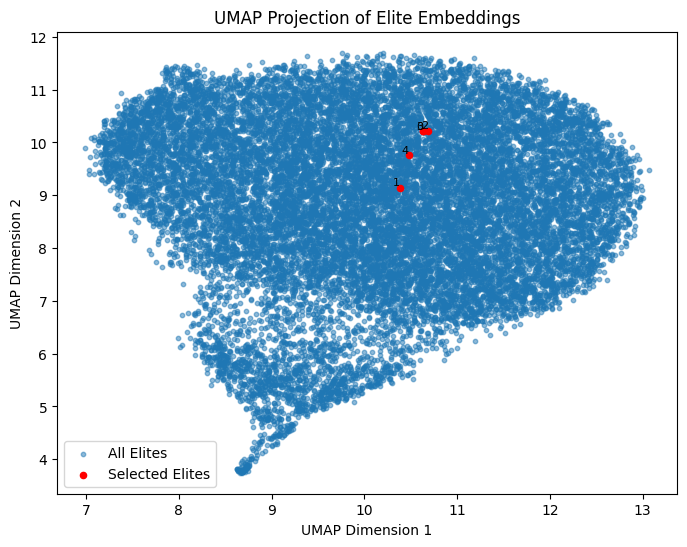

In [5]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
selected_elite_ids = [
  186.6234168344597,
  212.73606460409005,
  212.35639320138594,
  188.17250150497358,
  200.34257452090333
]


# Preserve order of elite_ids
id_to_elite = {elite["id"]: elite for elite in elites}
selected_elites = [id_to_elite[eid] for eid in selected_elite_ids if eid in id_to_elite]
selected_embeddings = [elite["embedding"] for elite in selected_elites]

reduced_points = []
for elite in selected_elites:
    embedding = elite["embedding"]
    point = umap_model.transform([embedding])[0]
    print(f"Elite ID {elite['id']} UMAP 2D coords: {point}")
    reduced_points.append(point)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            s=10, alpha=0.5, label="All Elites")

reduced_points = np.array(reduced_points)
plt.scatter(reduced_points[:, 0], reduced_points[:, 1],
            s=20, color="red", label="Selected Elites")

# Add numbering based on order in elite_ids
for i, (x, y) in enumerate(reduced_points):
    plt.text(x, y, str(i), fontsize=8, ha='right', va='bottom', color='black')

plt.title("UMAP Projection of Elite Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

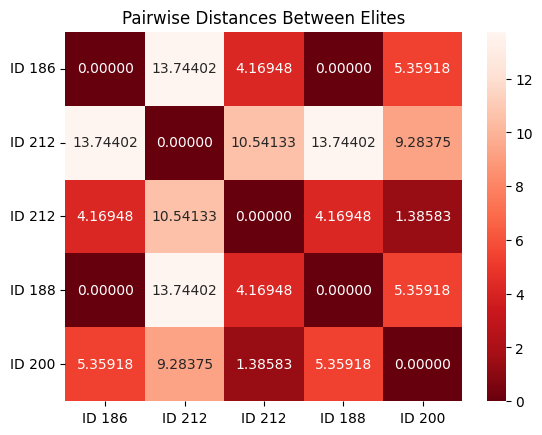

In [9]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

latent_distance_matrix = squareform(pdist(selected_embeddings, metric="euclidean"))

# shorten labels for readability
labels = [f"ID {int(id)}" for id in selected_elite_ids]

sns.heatmap(latent_distance_matrix, annot=True, cmap="Reds_r", xticklabels=labels, yticklabels=labels, fmt=".5f")
plt.title("Pairwise Distances Between Elites")
plt.yticks(rotation=0)
plt.show()

Elite ID: 186.6234168344597
Distances: [0.83026026 0.95835058 1.13518882 1.1572201  1.24730276 1.9238245
 2.15164801 2.65525107 2.70725545 3.01130409 3.28645295 3.66080641
 3.6783074  3.6783074  3.6783074  4.46684211 4.46684211 5.16689147
 5.36010992 5.80543997 5.94477758 6.28116307 6.28116307 6.28116307
 7.31764858 7.31764858 7.46504264 7.9530839  7.9530839  8.91398984]
Mean distance to neighbors: 4.42449
---


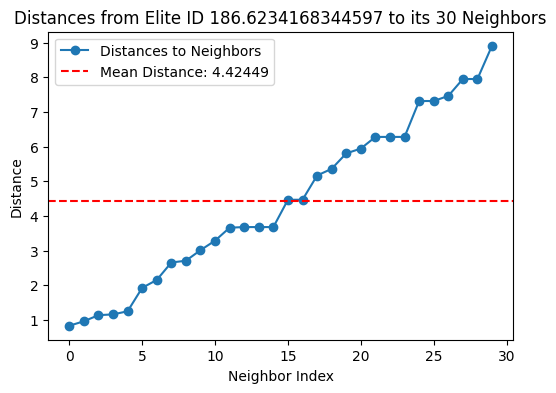

Elite ID: 212.73606460409005
Distances: [1.3384303  1.62339914 1.7317659  1.92535643 1.96157816 2.00404866
 2.07787969 2.10802861 2.15714848 2.182075   2.24577761 2.4122864
 2.43162452 2.4373168  2.45080161 2.45386066 2.50655556 2.56927615
 2.58082536 2.58296733 2.61064189 2.77161057 2.800946   2.81302025
 2.83172795 2.8623197  2.88837336 2.89744485 2.92503906 3.11437443]
Mean distance to neighbors: 2.40988
---


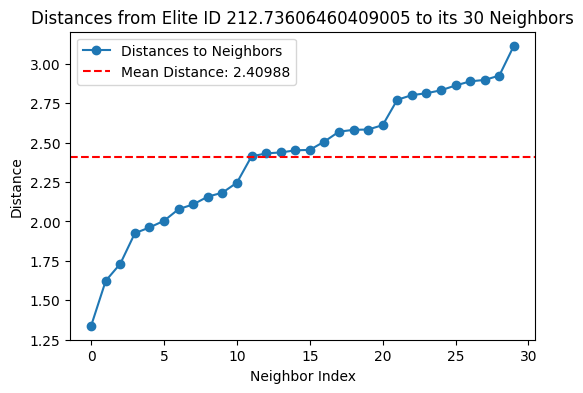

Elite ID: 212.35639320138594
Distances: [1.36758925 1.39567635 1.58951172 1.58951172 2.16537681 2.44109439
 2.44109439 2.44109439 2.44330625 2.77304678 2.89570253 2.97628781
 3.17505105 3.17505105 3.17505105 3.18241825 3.30581177 3.4129486
 3.49058946 3.5895531  3.74331228 4.15126701 4.3087431  4.74665425
 5.01853138 5.01853138 5.14034136 5.16124885 5.34544002 5.39171221]
Mean distance to neighbors: 3.36838
---


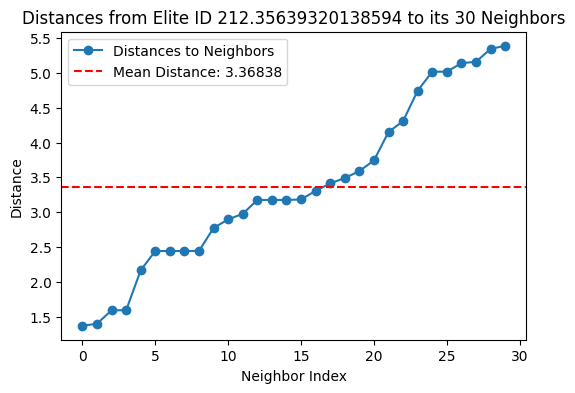

Elite ID: 188.17250150497358
Distances: [0.83026026 0.95835058 1.13518882 1.1572201  1.24730276 1.9238245
 2.15164801 2.65525107 2.70725545 3.01130409 3.28645295 3.66080641
 3.6783074  3.6783074  3.6783074  4.46684211 4.46684211 5.16689147
 5.36010992 5.80543997 5.94477758 6.28116307 6.28116307 6.28116307
 7.31764858 7.31764858 7.46504264 7.9530839  7.9530839  8.91398984]
Mean distance to neighbors: 4.42449
---


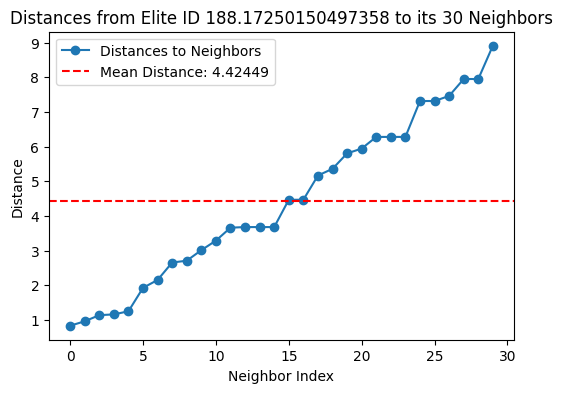

Elite ID: 200.34257452090333
Distances: [0.19053006 1.53494146 1.53494146 1.62872384 1.91788069 2.07639124
 2.15327743 2.15327743 2.15327743 2.40687284 2.77701796 2.77701796
 2.77701796 2.95002844 3.53784765 3.78730641 3.99887292 4.0908547
 4.09748793 4.19795559 4.19795559 4.2909648  4.34969696 4.41827285
 4.42242566 4.44873232 4.45048198 4.45048198 4.59283524 4.68218906]
Mean distance to neighbors: 3.23485
---


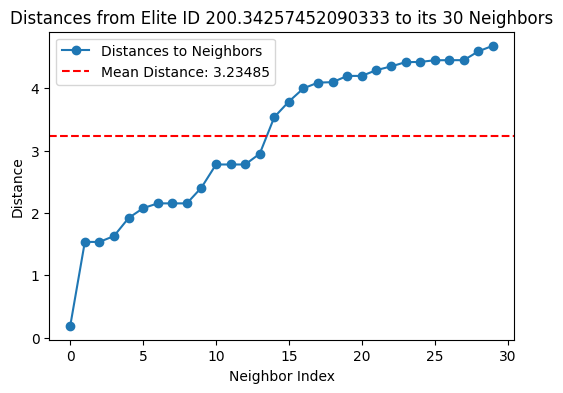

In [10]:
# compute kNeighbors for each elite
from sklearn.neighbors import NearestNeighbors


elites_minus_selected = [elite for elite in elites if elite["id"] not in selected_elite_ids]

elite_embeddings = [elite["embedding"] for elite in elites_minus_selected]

n_neighbors = 30
knn = NearestNeighbors(n_neighbors=n_neighbors)
knn.fit(elite_embeddings)

for i, elite in enumerate(selected_elites):
    elite_id = elite["id"]
    elite_embedding = elite["embedding"]
    distances, indices = knn.kneighbors([elite_embedding])
    mean_distance = np.mean(distances)
    print(f"Elite ID: {elite_id}")
    print(f"Distances: {distances[0]}")
    print(f"Mean distance to neighbors: {mean_distance:.5f}")
    print("---")
    # plot distances and mean distance
    plt.figure(figsize=(6, 4))
    plt.plot(distances[0], marker='o', label='Distances to Neighbors')
    plt.axhline(mean_distance, color='red', linestyle='--', label=f'Mean Distance: {mean_distance:.5f}')
    plt.title(f"Distances from Elite ID {elite_id} to its {n_neighbors} Neighbors")
    plt.xlabel("Neighbor Index")
    plt.ylabel("Distance")
    plt.legend()
    plt.show()
    
    


##### mean neighbor distance for top 5 and bottom 5 elites by sub_count

##### mean distance in embedding space of umap clusters

In [11]:
k = 15
X = np.array(_embeddings)
knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
knn.fit(X)


near_ids = [444.22041405950336, 652.4195413315717, 894.5473669528045]
near_elites = [elite for elite in elites if elite["id"] in near_ids]

sparse_ids = [979.6166047852373,995.6815485034725, 439.2284344674571]
sparse_elites = [elite for elite in elites if elite["id"] in sparse_ids]

near_distances = get_mean_k_distance(knn, near_elites, k)
print("\n--- Near Elites: Mean Neighborhood Distance (k={k}) ---")
for eid, dist in near_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

sparse_distances = get_mean_k_distance(knn, sparse_elites, k)
print("\n--- Sparse Elites: Mean Neighborhood Distance (k={k}) ---")
for eid, dist in sparse_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

maxY = max(max([dist for _, dist in near_distances]), max([dist for _, dist in sparse_distances])) * 1.1

plt.figure(figsize=(6, 3))
plt.bar(x=[str(int(eid)) for eid, _ in near_distances], height=[dist for _, dist in near_distances], color='blue')

plt.bar(x=[str(int(eid)) for eid, _ in sparse_distances], height=[dist for _, dist in sparse_distances], color='red')
plt.title("Near vs Sparse Elites mean neighborhood distance")
plt.ylabel("Mean Distance")
plt.ylim(0, maxY)

# Add legend
plt.legend(["Near Elites", "Sparse Elites"])

plt.show()



NameError: name 'get_mean_k_distance' is not defined